This notebook reproduces the example from scDesign3 package: [Simulate datasets with batch effect](https://songdongyuan1994.github.io/scDesign3/docs/articles/scDesign3-batchEffect-vignette.html)

In [1]:
from scdesigner.datasets import batch

exper = batch()

In [2]:
exper = exper[:, :100].to_memory()
exper.obs

,phenoid,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,percent.mito,Cluster,Experiment,Method,ident,batch,cell_type
pbmc2_10X_V2_AAACCTGAGATGGGTC,B cell,pbmc2,2360.0,1044,1044,2360,0.0419491525423729,2,pbmc2,10x Chromium (v2),pbmc2,10x Chromium (v2),B cell
pbmc2_10X_V2_AAACCTGAGCGTAATA,B cell,pbmc2,1888.0,803,803,1888,0.0413135593220339,2,pbmc2,10x Chromium (v2),pbmc2,10x Chromium (v2),B cell
pbmc2_10X_V2_AAACCTGAGCTAGGCA,Cytotoxic T cell,pbmc2,3456.0,1372,1372,3456,0.0353009259259259,1,pbmc2,10x Chromium (v2),pbmc2,10x Chromium (v2),Cytotoxic T cell
pbmc2_10X_V2_AAACCTGAGGGTCTCC,Dendritic cell,pbmc2,3802.0,1519,1519,3802,0.0420831141504471,6,pbmc2,10x Chromium (v2),pbmc2,10x Chromium (v2),Dendritic cell
pbmc2_10X_V2_AAACCTGGTCCGAACC,CD4+ T cell,pbmc2,3826.0,1451,1451,3826,0.0371144798745426,0,pbmc2,10x Chromium (v2),pbmc2,10x Chromium (v2),CD4+ T cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...
pbmc1_10x_v3_TCATGCCCAATGAAAC,Dendritic cell,pbmc1,13524.0,3042,3042,13524,0.0936113575865129,8,pbmc1,10x Chromium (v3),pbmc1,10x Chromium (v3),Dendritic cell
pbmc1_10x_v3_TCCTTTCGTGCGAGTA,Dendritic cell,pbmc1,15400.0,3166,3166,15400,0.0883766233766234,8,pbmc1,10x Chromium (v3),pbmc1,10x Chromium (v3),Dendritic cell
pbmc1_10x_v3_TGTGATGCATCATCTT,Dendritic cell,pbmc1,15566.0,3303,3303,15566,0.0920596171142233,8,pbmc1,10x Chromium (v3),pbmc1,10x Chromium (v3),Dendritic cell
pbmc1_10x_v3_TTGAACGCATGCAGCC,Dendritic cell,pbmc1,16389.0,3361,3361,16389,0.0961010433827567,8,pbmc1,10x Chromium (v3),pbmc1,10x Chromium (v3),Dendritic cell


This is not quite the simulator used in the scDesign3 vignette, because we are using the same copula correlation across all groups. We need a version of negative_binomial_copula that takes a grouping variable in the formula as well.

In [3]:
from scdesigner.simulators import NegBinCopula

formula = "~ cell_type + batch"
sim = NegBinCopula(mean_formula=formula)
sim.fit(exper, max_epochs=10)

Epoch 10/10, Loss: 1.3844, Val Loss: 1.4133


Estimating copula correlation: 100%|██████████| 7/7 [00:00<00:00, 26.74it/s]


In [4]:
synthetic = sim.sample()

In [5]:
import scdesigner.transform as tr

sim_null = tr.nullify(sim, row_pattern="batch", col_pattern=exper.var_names, param="mean")
synthetic_null = sim_null.sample(exper.obs)

In [6]:
import numpy as np

new_value = np.random.normal(5, 2, (10, 100))
sim_alter = tr.replace_param(sim=sim, path=["marginal", "mean"], new_param=new_value)
synthetic_alter = sim_alter.sample(exper.obs)

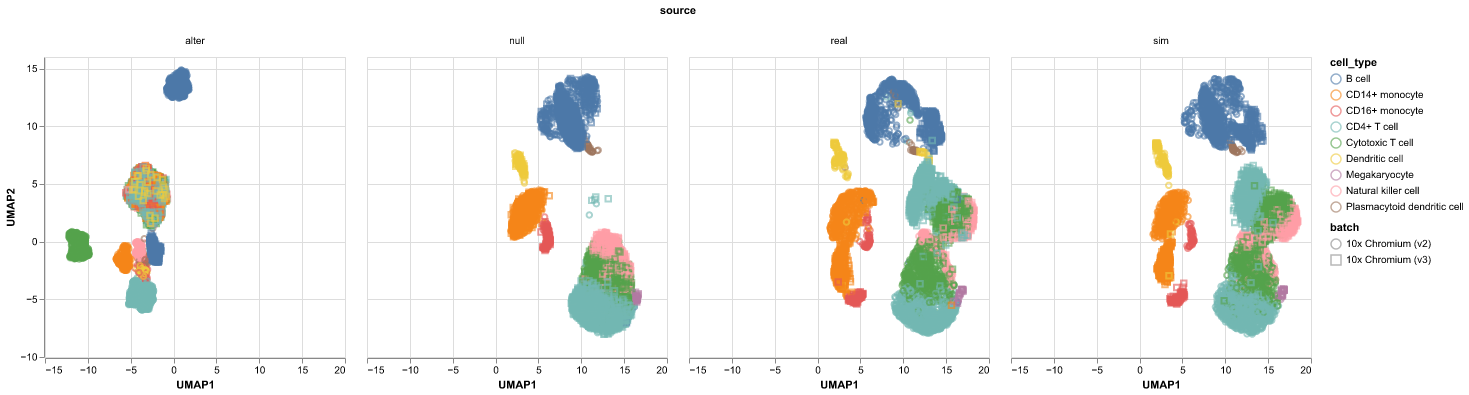

In [8]:
import altair
import anndata
from scdiagnostics import plot_umap
altair.renderers.enable('png')
altair.data_transformers.enable("vegafusion")

combined = anndata.concat({"real": exper, "sim": synthetic, "null": synthetic_null, "alter": synthetic_alter}, label="source")
plot_umap(combined, color="cell_type", shape="batch", facet="source")